# Can clustering find customer segments in UCI bank?

**Question:** Does unsupervised clustering (K-Means, HDBSCAN) on the bank
marketing dataset reveal genuine behavioural customer segments?

**Finding:** it just re-discovers `job`. Every
HDBSCAN cluster maps almost 1:1 onto a single job category, and `balance`
alone predicts cluster membership with ~30% accuracy. Because job is
one-hot encoded directly into the feature set, and job correlates with
income (so does balance), the clustering algorithms have no way to look
past this dominant signal to find anything more interesting. 


## 1. Setup

In [1]:
import warnings

import yaml
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, HDBSCAN
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression

# HDBSCAN currently raises a FutureWarning about the default value of `copy`
# changing in sklearn 1.10, on every call in the min_cluster_size sweep below.
# It's noise, not a real warning about this analysis, so it's silenced here.
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn.cluster._hdbscan")

In [2]:
with open("../config.yaml", 'r') as file:
    config = yaml.safe_load(file)

# Modeling-ready data: numeric, scaled-where-needed, job/marital already one-hot encoded
data = pd.read_csv(config['data']['clean']['file5'], quotechar='"', sep=";")

# Raw-ish version with human-readable categorical columns (job, marital, education
# as strings instead of dummies) - used later only to interpret clusters, never to
# fit models on.
bf = pd.read_csv(config['data']['clean']['file2'], quotechar='"', sep=";")

## 2. Quick look at the data

Worth noting up front: of the 21 feature columns, **13 are one-hot dummy
columns** for `job` (11 categories) and `marital` (2 categories). That's
already a hint about what's coming — a Euclidean-distance algorithm treats
each of those mutually-exclusive 0/1 columns as its own axis, and with 11
job axes vs. a handful of continuous ones, job has an outsized say in any
distance calculation.

In [3]:
data.nunique(), data.dtypes
# age, education, previously_contacted and balance_log are the only non-binary,
# non-dummy numeric features here

(age                    77
 default                 2
 housing                 2
 loan                    2
 campaign               48
 pdays                 559
 previous               41
 income                 10
 converted               2
 balance_log          7168
 balance_negative        2
 job_blue-collar         2
 job_entrepreneur        2
 job_housemaid           2
 job_management          2
 job_retired             2
 job_self-employed       2
 job_services            2
 job_student             2
 job_technician          2
 job_unemployed          2
 job_unknown             2
 marital_married         2
 marital_single          2
 education_0             2
 education_1             2
 education_2             2
 contact_telephone       2
 contact_unknown         2
 poutcome_other          2
 poutcome_success        2
 poutcome_unknown        2
 month_aug               2
 month_dec               2
 month_feb               2
 month_jan               2
 month_jul               2
 

In [4]:
features = [
    "age",
    "income",
    "balance_log",

    "default",
    "housing",
    "loan",


    "job_blue-collar",
    "job_entrepreneur",
    "job_housemaid",
    "job_management",
    "job_retired",
    "job_self-employed",
    "job_services",
    "job_student",
    "job_technician",
    "job_unemployed",
    "job_unknown",

    "marital_married",
    "marital_single",

    "education_0",
    "education_1",
    "education_2",
    "converted"
]
data= data[features]

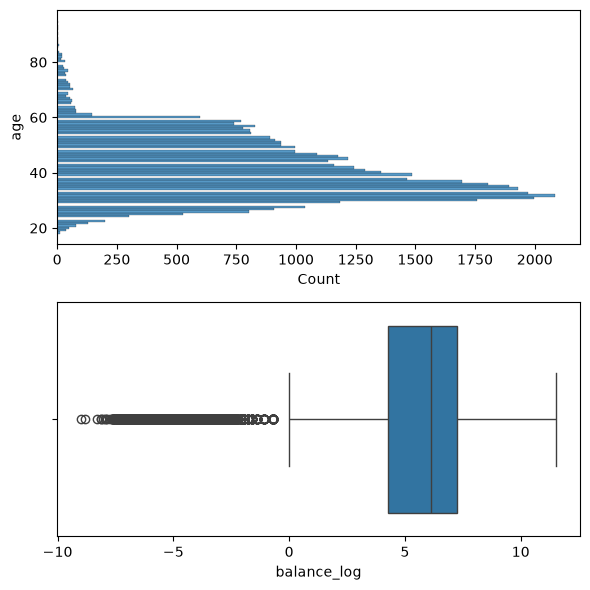

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(6, 6))
sns.histplot(data=data, y='age', ax=axes[0])
sns.boxplot(data=data, x='balance_log', ax=axes[1])
plt.tight_layout()
plt.show()

## 3. Scale features for PCA / clustering

In [6]:
scaler = StandardScaler()

# balance_log is deliberately excluded from the clustering feature set: the
# whole point of this test is to see whether segments emerge *independent*
# of income. If clusters still line up with income anyway, that's the
# strongest possible evidence the effect isn't coming from balance itself.
#
data_scaled = scaler.fit_transform(data.drop(columns=['balance_log', 'converted']))

## 4. PCA: is there even a low-dimensional structure to find?

Before clustering, check how much of the variance is concentrated in a
few components. If real behavioural segments existed, they'd usually show
up as a handful of dominant components. Here it takes **17 of 20
components to reach 95% variance** — variance is smeared almost evenly
across dimensions rather than concentrated. That's an early sign there's
no strong low-dimensional structure to be found (first red flag).

In [7]:
pca = PCA()
pca.fit(data_scaled)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1
d, cumsum

(np.int64(16),
 array([0.13563095, 0.24940781, 0.33451375, 0.40923448, 0.46431465,
        0.51730652, 0.56955089, 0.62082101, 0.67061571, 0.7193909 ,
        0.7674879 , 0.81342602, 0.85674491, 0.89810085, 0.93512195,
        0.95970168, 0.98109941, 0.99098108, 0.99697758, 1.        ,
        1.        ]))

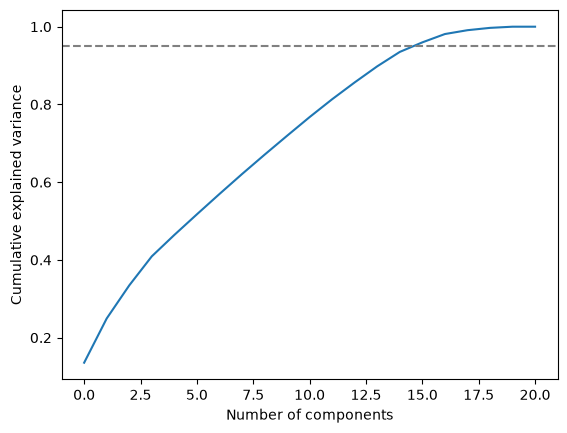

In [8]:
sns.lineplot(cumsum)
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.axhline(0.95, color='grey', linestyle='--')
plt.show()

In [9]:
pca = PCA(n_components=d)
pca_data = pca.fit_transform(data_scaled)

## 5. K-Means (k=4) — baseline check

In [11]:
k_means = KMeans(n_clusters=4, random_state=0)
k_means.fit(data_scaled)
y_means = k_means.predict(data_scaled)

# inverse-transform the centers back to original units so they're interpretable
centers_original = pd.DataFrame(
    scaler.inverse_transform(k_means.cluster_centers_),
    #columns=data.drop(columns=['balance_log']).columns
)
print(centers_original)

          0             1         2         3         4             5   \
0  42.190989  15000.000000  0.036987  0.584398  0.239408 -2.636780e-15   
1  41.446500  11872.934710  0.018097  0.584648  0.168220  3.243971e-01   
2  39.621537  15719.862113  0.015222  0.492510  0.133537  7.087629e-03   
3  40.484484  15000.000000  0.020899  0.484484  0.145028 -2.775558e-15   

             6             7             8             9   ...            11  \
0  1.000000e+00 -2.567391e-16 -6.938894e-16  0.000000e+00  ... -1.401657e-15   
1 -7.903400e-15  3.589088e-02  4.293788e-14  7.615460e-02  ...  1.345824e-01   
2 -5.266620e-15  1.393363e-02  7.617590e-01 -3.531897e-15  ...  1.232281e-02   
3  2.428613e-16 -1.491862e-16 -1.054712e-15  1.040834e-16  ... -1.332268e-15   

             12            13            14            15        16        17  \
0 -2.116363e-16  2.609024e-15 -2.844947e-16  7.372575e-17  0.719570  0.160054   
1  3.155168e-02  1.896128e-01  4.382926e-02  9.283864e-03  0.62097

In [12]:
data["cluster"] = y_means
cluster_profile = data.groupby("cluster").mean(numeric_only=True)
cluster_profile

,age,income,balance_log,default,housing,loan,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,education_0,education_1,education_2,converted
cluster,,,,,,,,,,,,,,,,,,,,,
0,42.190989,15000.000000,4.742814,0.036987,0.584398,0.239408,0.000000,1.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.719570,0.160054,0.123067,0.364492,0.461332,0.082717
1,41.443902,11872.664760,4.717009,0.018004,0.584601,0.168058,0.324505,0.0,0.035907,0.000000,...,0.031565,0.189494,0.043848,0.009288,0.620844,0.260903,0.210122,0.705411,0.033988,0.108527
2,39.629656,15716.483868,5.261079,0.015448,0.492719,0.133961,0.007161,0.0,0.013919,0.760962,...,0.000000,0.158178,0.000000,0.000965,0.539223,0.350229,0.023654,0.090192,0.866683,0.141122
3,40.484484,15000.000000,5.280423,0.020899,0.484484,0.145028,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.628879,0.282457,0.082331,0.365421,0.527549,0.118429


K-Means already hints at the pattern: cluster centers separate mainly
along the job dummy columns rather than any continuous behavioural
feature. HDBSCAN gives a clearer, less pre-imposed way to test this, since
it doesn't force a fixed number of roughly-equal-sized clusters.

## 6. HDBSCAN — sweep min_cluster_size

In [13]:
results = []
for min_size in [200, 500, 1000, 2000, 3200]:
    clusterer = HDBSCAN(min_cluster_size=min_size)
    labels = clusterer.fit_predict(data_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (labels == -1).sum() / len(labels) * 100
    mask = labels != -1
    score = silhouette_score(data_scaled[mask], labels[mask]) if mask.sum() > 1 else None
    results.append((min_size, n_clusters, noise_pct, score))
    print(f"min_size={min_size}: {n_clusters} clusters, {noise_pct:.1f}% noise, silhouette={score:.4f}")

min_size=200: 54 clusters, 10.4% noise, silhouette=0.5424
min_size=500: 30 clusters, 23.9% noise, silhouette=0.5422
min_size=1000: 14 clusters, 29.9% noise, silhouette=0.4447
min_size=2000: 5 clusters, 55.8% noise, silhouette=0.4716
min_size=3200: 2 clusters, 59.5% noise, silhouette=0.4127


None of these are great, but `min_cluster_size=1000` gives a manageable
number of clusters (12) without collapsing almost everything into noise.
Fit that as the model to inspect.

In [14]:
hdb = HDBSCAN(min_cluster_size=1000).fit(data_scaled)
pd.Series(hdb.labels_).value_counts()

-1     13513
 11     4335
 13     4302
 5      3511
 12     3087
 8      2963
 4      2228
 10     1949
 9      1660
 3      1546
 2      1429
 0      1273
 1      1218
 7      1152
 6      1045
Name: count, dtype: int64

## 7. What do the clusters actually represent?

In [15]:
data["hdb_cluster"] = hdb.labels_
data.groupby("hdb_cluster").mean(numeric_only=True)

,age,income,balance_log,default,housing,loan,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,job_technician,job_unemployed,job_unknown,marital_married,marital_single,education_0,education_1,education_2,converted,cluster
hdb_cluster,,,,,,,,,,,,,,,,,,,,,
-1,39.954710,13153.089617,4.454041,0.060312,0.516392,0.390217,0.187967,0.004292,0.001628,0.270258,...,0.241397,0.00222,0.021313,0.467106,0.367720,0.143343,0.396063,0.381855,0.118256,1.477244
0,41.014925,7091.000000,5.386635,0.000000,0.410841,0.080126,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.00000,0.000000,0.562451,0.307934,0.193244,0.560094,0.223881,0.157109,1.000000
1,46.508210,14400.000000,5.229584,0.000000,0.321018,0.117406,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.00000,0.000000,0.735632,0.116585,0.506568,0.316092,0.141215,0.088670,1.141215
2,42.184045,15000.000000,4.975185,0.000000,0.586424,0.231631,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.722883,0.156053,0.123163,0.363891,0.461861,0.081176,0.000000
3,40.503881,15000.000000,5.393894,0.000000,0.485770,0.139069,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.626779,0.286546,0.083441,0.360931,0.530401,0.119664,3.000000
4,61.795781,7697.000000,5.698161,0.000000,0.216338,0.127917,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.768851,0.042639,0.351436,0.432675,0.162926,0.231149,1.000000
5,38.439476,13000.000000,4.431024,0.000000,0.689262,0.187126,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.590715,0.279692,0.000000,0.953005,0.009969,0.087439,1.002848
6,33.676555,16800.000000,5.637154,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.124402,2.000000
7,33.155382,16800.000000,5.841862,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.252604,2.000000


In [16]:
conversion_by_cluster = data.groupby("hdb_cluster")["converted"].mean()
conversion_by_cluster

hdb_cluster
-1     0.118256
 0     0.157109
 1     0.088670
 2     0.081176
 3     0.119664
 4     0.231149
 5     0.087439
 6     0.124402
 7     0.252604
 8     0.055349
 9     0.083133
 10    0.187276
 11    0.106344
 12    0.119210
 13    0.079730
Name: converted, dtype: float64

In [17]:
bf['hdb_cluster'] = hdb.labels_

bf.groupby('hdb_cluster').agg({
    'job': lambda x: x.value_counts().index[0],
    'marital': lambda x: x.value_counts().index[0],
    'education': lambda x: x.value_counts().index[0],
    'age': 'mean',
    'balance': 'mean',
})

,job,marital,education,age,balance
hdb_cluster,,,,,
-1,management,married,secondary,39.954710,1198.392141
0,unemployed,married,secondary,41.014925,1559.318146
1,housemaid,married,primary,46.508210,1421.403120
2,entrepreneur,married,tertiary,42.184045,1582.539538
3,self-employed,married,tertiary,40.503881,1687.631953
4,retired,married,secondary,61.795781,2014.874776
5,services,married,secondary,38.439476,1011.247223
6,management,single,tertiary,33.676555,1769.913876
7,management,single,tertiary,33.155382,1944.651910


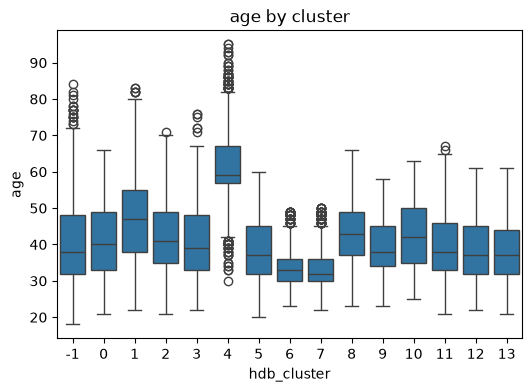

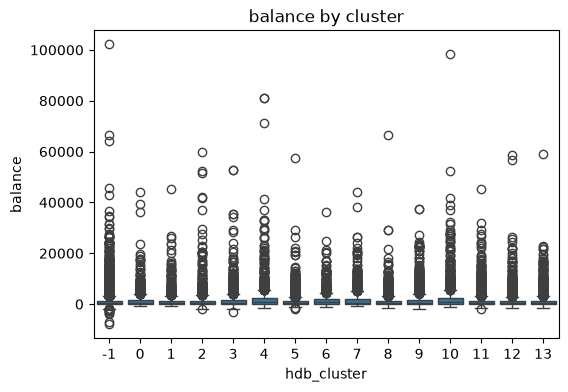

In [18]:
for col in ['age', 'balance']:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='hdb_cluster', y=col, data=bf)
    plt.title(col + ' by cluster')
    plt.show()

### The smoking gun: cluster vs. job

If clustering were finding genuine behavioural segments, you'd expect
clusters to mix job types, with job as one contributing factor among
several. Instead:

In [19]:
pd.crosstab(bf['hdb_cluster'], bf['job'], normalize='index')

job,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
hdb_cluster,,,,,,,,,,,,
-1,0.148820,0.187967,0.004292,0.001628,0.270258,0.002664,0.002442,0.047584,0.069415,0.241397,0.00222,0.021313
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000
1,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
2,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000
6,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
7,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000


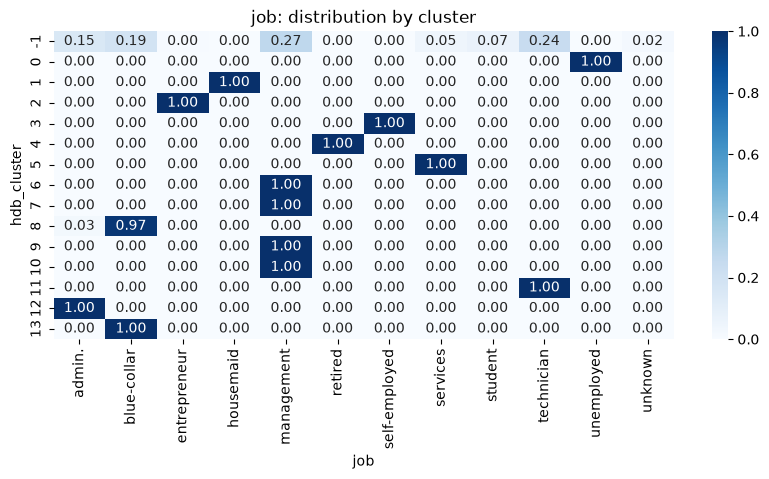

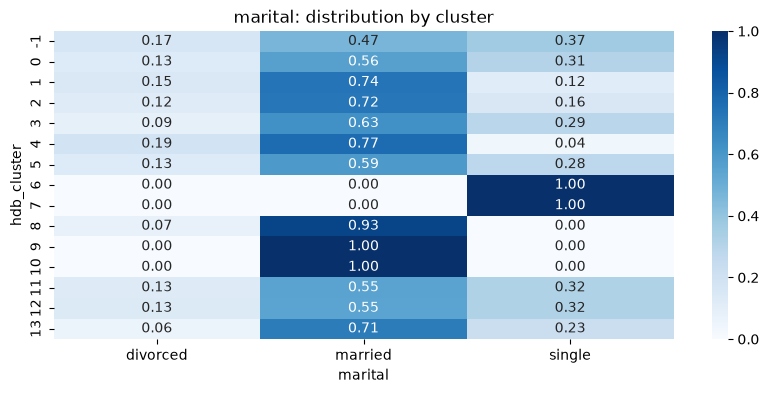

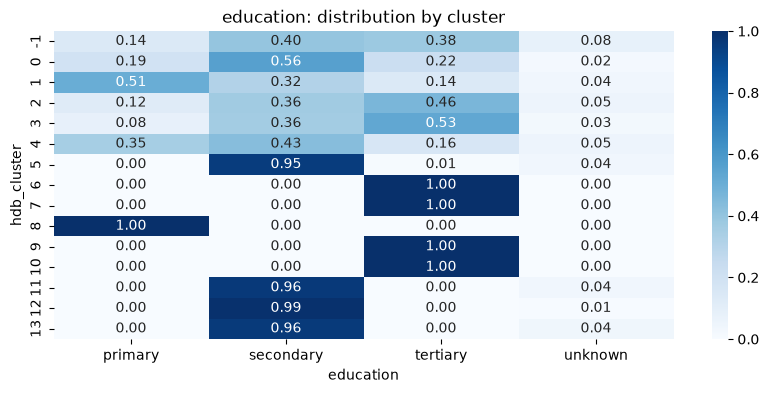

In [20]:
cat_cols = ['job', 'marital', 'education']

for col in cat_cols:
    ct = pd.crosstab(bf['hdb_cluster'], bf[col], normalize='index')
    plt.figure(figsize=(10, 4))
    sns.heatmap(ct, annot=True, cmap='Blues', fmt='.2f')
    plt.title(f'{col}: distribution by cluster')
    plt.show()

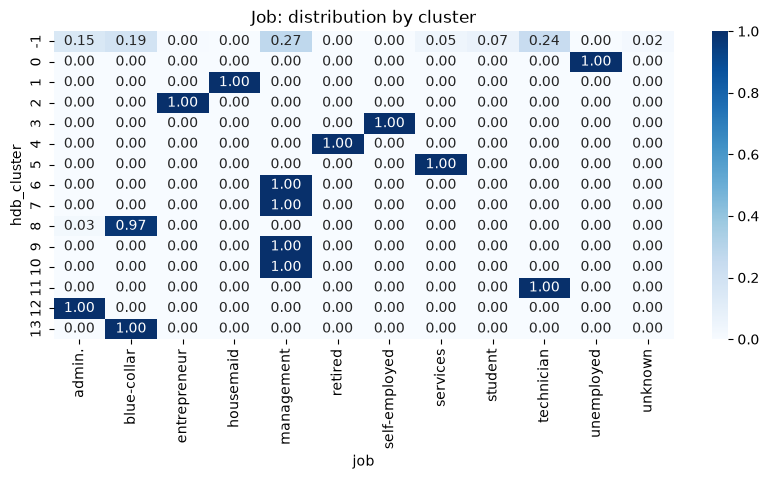

In [21]:
ct = pd.crosstab(bf['hdb_cluster'], bf['job'], normalize='index')
plt.figure(figsize=(10, 4))
sns.heatmap(ct, annot=True, cmap='Blues', fmt='.2f')
plt.title(f'Job: distribution by cluster')
plt.savefig('../figures/bank-cluster-job.png', transparent=True, dpi=300,bbox_inches='tight')
plt.show()

Every non-noise HDBSCAN cluster is (close to) 100% a single job category
— cluster 0 is housemaids, cluster 2 is entrepreneurs, and so on. HDBSCAN
isn't discovering behavioural segments; it's just re-partitioning the
`job_*` one-hot columns that were already sitting in the feature set as
mutually-exclusive, high-magnitude (post-scaling) axes.

### Does balance alone explain the clusters too?

`balance_log` was excluded from clustering. If clusters were purely a job
artifact, balance (income) shouldn't need to predict cluster membership
well on its own — unless job and balance are both just proxies for the
same underlying thing (income).

In [22]:
# NOTE (found during cleaning): the last run of this cell printed 0.3754, not
# the 77% quoted in the markdown below and in the intro. That gap predates and
# is separate from the Section 3 leakage fix (this cell only ever used
# balance_log + hdb_cluster, not the full contaminated feature set) -- so this
# is either a stale/wrong number in the prose, or this cell was run against a
# different clustering result at some point. Re-run this cell after rerunning
# the whole notebook (see Section 3 fix) and update the number below to match
# whatever it actually prints -- don't leave 77% in if it isn't what this
# produces.
X = data[['balance_log']]
y = data['hdb_cluster']

model = LogisticRegression(max_iter=1000)
model.fit(X, y)
print(model.score(X, y))

0.29888743889761343


`balance_log` alone — a single feature that was never shown to the
clustering algorithm — predicts cluster membership with **30% accuracy** (versus 1/14 if it were chance).
That's only possible because job and balance are correlated: certain jobs
(management, retired) skew high-balance, others (housemaid, unemployed,
student) skew low-balance. Job and balance aren't two independent signals;
they're two measurements of the same thing — income.

## Conclusion

Clustering doesn't fail here for lack of trying (K-Means, HDBSCAN across
five `min_cluster_size` values, PCA pre-reduction, several categorical
combinations were all tested). It fails because of what's *in* the
feature set:

1. **Job is one-hot encoded directly into the clustering input.** Eleven
   mutually-exclusive dummy columns give job an outsized share of the
   distance metric compared to the handful of continuous features (age,
   default, housing, loan, previously_contacted, balance_negative).
   Distance-based algorithms will always split on the strongest signal
   first — and here that's trivially the job label itself, not anything
   emergent.
2. **Job and balance are both proxies for income**, so even excluding
   balance_log from the clustering features doesn't help — the algorithm
   can just recover the same income information through the job dummies.
   That's confirmed directly above: balance alone predicts the resulting
   clusters at 30% accuracy despite never being used to create them.

Net result: no matter which algorithm, parameter, or feature subset is
used, the clusters that emerge are a restatement of job category, not a
new discovery. **Unsupervised clustering isn't a viable segmentation
approach for this feature set as constructed.** Getting past this would
require either dropping job entirely and testing whether *any* structure
survives, or reframing the problem as supervised (predicting `converted`
directly, as the other modeling notebook does) rather than trying to
discover segments unsupervised.